When you extract frequent itemsets (words or sets of words that appear together often across your sentences), you reveal underlying structure:

Sentences that share many frequent itemsets are likely to be similar—for example, about the same topic or intent.

This means your sentences can be grouped (clustered) based on how much they “share” these itemsets.

# André

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data

In [134]:
data = pd.read_csv('../data/horoscope_saved.csv')
data.columns
data = data.head(1000)

# this dataset is not real is generated for demonstration purposes only

In [135]:
data.rename(columns={'horoscope': 'token'}, inplace=True)

In [136]:
data["token"][0]=",,,..,.,:;!?? hallo Hallo hallo this is a"

/var/folders/7n/g80l5_jd4fdc9g9m7qbj6mdr0000gn/T/ipykernel_26243/3093203913.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data["token"][0]=",,,..,.,:;!?? hallo Hallo hallo this is a"
/var/folders/7n/g80l5_jd4fdc9g9m7qbj6mdr0000gn/T/ipy

In [137]:
data

,sign,category,date,token
0,aries,general,20200617,",,,..,.,:;!?? hallo Hallo hallo this is a"
1,aries,general,20200618,People will understand and appreciate your des...
2,aries,general,20200619,You are very interested in technological break...
3,aries,general,20200620,Stress from overwork could have you feeling we...
4,aries,general,20200621,This is a good day to stand up for yourself an...
...,...,...,...,...
995,aries,career,20210307,The week is off to a slow start for you and yo...
996,aries,career,20210308,Don't be afraid to let your sensitive side shi...
997,aries,career,20210309,The burst of energy that you have been hoping ...
998,aries,career,20210310,"It will be hard to say ""no"" to anyone or anyth..."


stats about size of tweets

In [138]:
import re

def clean_keep_apostrophe(text):
    # Only keep letters, digits, apostrophes, and whitespace
    return re.sub(r"[^\w\d'\s]", "", text)

# Apply to your DataFrame
data['token'] = data['token'].apply(clean_keep_apostrophe)
data['token'] = data['token'].str.split()

In [139]:
data.head()

,sign,category,date,token
0,aries,general,20200617,"[hallo, Hallo, hallo, this, is, a]"
1,aries,general,20200618,"[People, will, understand, and, appreciate, yo..."
2,aries,general,20200619,"[You, are, very, interested, in, technological..."
3,aries,general,20200620,"[Stress, from, overwork, could, have, you, fee..."
4,aries,general,20200621,"[This, is, a, good, day, to, stand, up, for, y..."


In [140]:
data["original_token_size"] = data["token"].apply(len)
data["original_token_size"].describe()

count    1000.000000
mean       60.487000
std        10.493519
min         6.000000
25%        49.000000
50%        65.000000
75%        68.000000
max        87.000000
Name: original_token_size, dtype: float64

In [141]:
data

,sign,category,date,token,original_token_size
0,aries,general,20200617,"[hallo, Hallo, hallo, this, is, a]",6
1,aries,general,20200618,"[People, will, understand, and, appreciate, yo...",71
2,aries,general,20200619,"[You, are, very, interested, in, technological...",52
3,aries,general,20200620,"[Stress, from, overwork, could, have, you, fee...",73
4,aries,general,20200621,"[This, is, a, good, day, to, stand, up, for, y...",65
...,...,...,...,...,...
995,aries,career,20210307,"[The, week, is, off, to, a, slow, start, for, ...",48
996,aries,career,20210308,"[Don't, be, afraid, to, let, your, sensitive, ...",46
997,aries,career,20210309,"[The, burst, of, energy, that, you, have, been...",47
998,aries,career,20210310,"[It, will, be, hard, to, say, no, to, anyone, ...",43


In [142]:
data["token"] = data["token"].apply(lambda x: [w.lower() for w in x])

In [143]:
data

,sign,category,date,token,original_token_size
0,aries,general,20200617,"[hallo, hallo, hallo, this, is, a]",6
1,aries,general,20200618,"[people, will, understand, and, appreciate, yo...",71
2,aries,general,20200619,"[you, are, very, interested, in, technological...",52
3,aries,general,20200620,"[stress, from, overwork, could, have, you, fee...",73
4,aries,general,20200621,"[this, is, a, good, day, to, stand, up, for, y...",65
...,...,...,...,...,...
995,aries,career,20210307,"[the, week, is, off, to, a, slow, start, for, ...",48
996,aries,career,20210308,"[don't, be, afraid, to, let, your, sensitive, ...",46
997,aries,career,20210309,"[the, burst, of, energy, that, you, have, been...",47
998,aries,career,20210310,"[it, will, be, hard, to, say, no, to, anyone, ...",43


# Itemsets

In [9]:
data["original_sentence"] = data["token"]
longer_data = data.explode('token').rename(columns={'token': 'word'})
longer_data['word'] = longer_data['word'].str.lower()

longer_data

,sign,category,date,word,original_token_size,original_sentence
0,aries,general,20200617,NaN,0,[]
1,aries,general,20200618,people,71,"[People, will, understand, and, appreciate, yo..."
1,aries,general,20200618,will,71,"[People, will, understand, and, appreciate, yo..."
1,aries,general,20200618,understand,71,"[People, will, understand, and, appreciate, yo..."
1,aries,general,20200618,and,71,"[People, will, understand, and, appreciate, yo..."
...,...,...,...,...,...,...
21958,pisces,birthday,20210616,that,121,"[You, will, probably, enjoy, being, the, cente..."
21958,pisces,birthday,20210616,comes,121,"[You, will, probably, enjoy, being, the, cente..."
21958,pisces,birthday,20210616,naturally,121,"[You, will, probably, enjoy, being, the, cente..."
21958,pisces,birthday,20210616,to,121,"[You, will, probably, enjoy, being, the, cente..."


Word counter!

In [10]:
word_counter = longer_data['word'].value_counts().reset_index()
word_counter.columns = ['word', 'count']

# Show the counts
word_counter.head(20)

,word,count
0,you,75847
1,and,57958
2,to,57957
3,the,50711
4,your,40128
5,a,39870
6,in,35492
7,of,29045
8,be,27586
9,is,19255


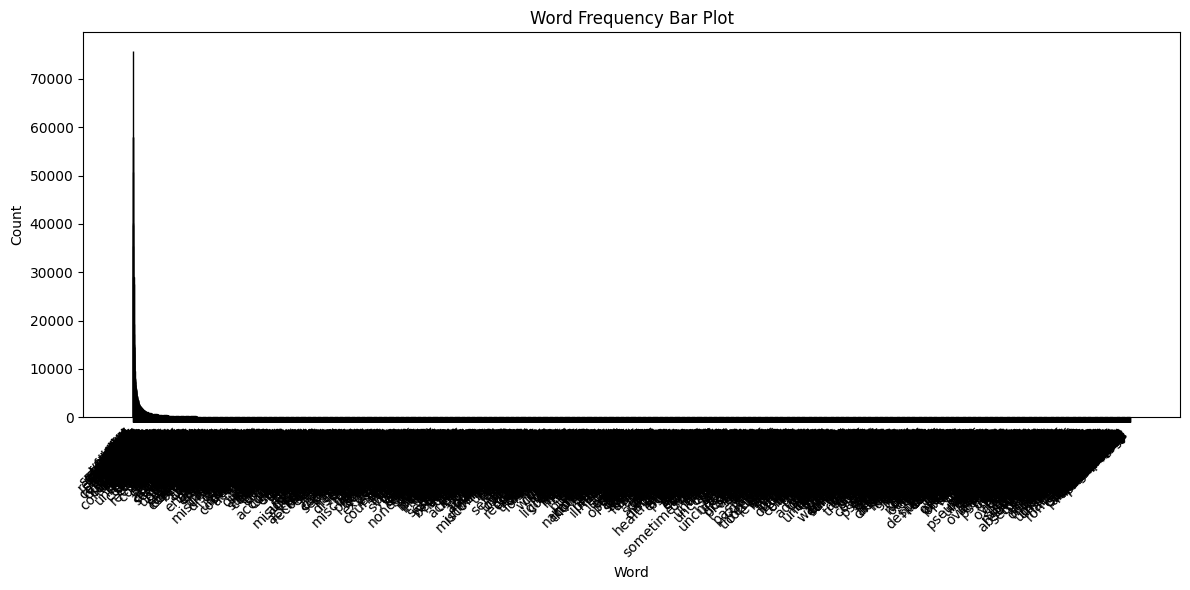

In [11]:
# Sort word_counter by count descending (already done by value_counts)
word_counter_sorted = word_counter.sort_values(by='count', ascending=False)

# Plot bar plot: each bar for one word, ordered by frequency
plt.figure(figsize=(12, 6))
plt.bar(word_counter_sorted['word'], word_counter_sorted['count'], color='skyblue', edgecolor='black')

plt.title('Word Frequency Bar Plot')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability

plt.tight_layout()
plt.show()

In [12]:
# Find frequent itemsets (count-based, no external libraries)
# Configurable parameters
min_support = 0.02   # minimum support (fraction of transactions)
max_k = 3           # maximum size of itemsets to search (1..max_k)

from collections import Counter
from itertools import combinations

# Prepare transactions: list of token lists (unique items per transaction)
transactions = [list(dict.fromkeys(t)) for t in data['token'].tolist()]
num_tx = len(transactions)

print(f"Number of transactions: {num_tx}")

def get_frequent_itemsets(transactions, max_k=2, min_support=0.05):
    n = len(transactions)
    results = []  # list of dicts: {'itemset': tuple, 'count': int, 'support': float}

    # Count single items
    single_counts = Counter()
    for t in transactions:
        single_counts.update(set(t))

    # collect frequent 1-itemsets
    prev_freq = {}
    for item, cnt in single_counts.items():
        support = cnt / n
        if support >= min_support:
            results.append({'itemset': (item,), 'count': cnt, 'support': support})
            prev_freq[(item,)] = cnt

    # iterate for k = 2..max_k
    k = 2
    while k <= max_k and prev_freq:
        candidate_counts = Counter()
        for t in transactions:
            items = sorted(set(t))
            if len(items) < k:
                continue
            for comb in combinations(items, k):
                candidate_counts[comb] += 1

        # filter by min_support
        freq_k = {}
        for comb, cnt in candidate_counts.items():
            support = cnt / n
            if support >= min_support:
                results.append({'itemset': comb, 'count': cnt, 'support': support})
                freq_k[comb] = cnt

        prev_freq = freq_k
        k += 1

    # return results as DataFrame sorted by k and support desc
    if not results:
        return pd.DataFrame(columns=['itemset','count','support','k'])

    df = pd.DataFrame(results)
    df['k'] = df['itemset'].apply(len)
    df = df.sort_values(['k','support'], ascending=[True, False]).reset_index(drop=True)
    return df

# Run the mining
freq_itemsets_df = get_frequent_itemsets(transactions, max_k=max_k, min_support=min_support)

if freq_itemsets_df.empty:
    print("No frequent itemsets found with the current min_support and max_k.")
else:
    display(freq_itemsets_df)

# Optional: save to CSV
# freq_itemsets_df.to_csv('../data/frequent_itemsets.csv', index=False)

# Quick summary: top itemsets by support
print('\nTop itemsets by support:')
print(freq_itemsets_df.head(20))

Number of transactions: 21959


,itemset,count,support,k
0,"(you,)",20801,0.947265,1
1,"(to,)",20456,0.931554,1
2,"(the,)",18779,0.855185,1
3,"(and,)",18738,0.853318,1
4,"(your,)",17633,0.802996,1
...,...,...,...,...
72066,"(a, great, month)",440,0.020037,3
72067,"(family, in, more)",440,0.020037,3
72068,"(all, friends, work)",440,0.020037,3
72069,"(to, world, year)",440,0.020037,3



Top itemsets by support:
    itemset  count   support  k
0    (you,)  20801  0.947265  1
1     (to,)  20456  0.931554  1
2    (the,)  18779  0.855185  1
3    (and,)  18738  0.853318  1
4   (your,)  17633  0.802996  1
5      (a,)  17525  0.798078  1
6     (of,)  16133  0.734687  1
7     (in,)  14662  0.667699  1
8     (be,)  13601  0.619382  1
9     (is,)  12474  0.568059  1
10  (that,)  11794  0.537092  1
11  (with,)  10429  0.474931  1
12   (for,)  10188  0.463956  1
13   (You,)  10070  0.458582  1
14  (will,)   9965  0.453800  1
15   (may,)   9860  0.449019  1
16   (are,)   9406  0.428344  1
17  (this,)   8937  0.406986  1
18    (it,)   8935  0.406895  1
19  (have,)   8570  0.390273  1


In [16]:
freq_itemsets_df.to_csv('../data/frequent_itemsets.csv', index=False)

In [17]:
# Show only 1-itemsets (k == 1). Use a safe check in case the 'k' column is missing.
if 'k' in freq_itemsets_df.columns:
    display(freq_itemsets_df[freq_itemsets_df['k'] != 1])
else:
    print("DataFrame has no 'k' column. Available columns:", freq_itemsets_df.columns.tolist())

,itemset,count,support,k
451,"(to, you)",19368,0.882007,2
452,"(the, you)",17790,0.810146,2
453,"(and, you)",17749,0.808279,2
454,"(the, to)",17452,0.794754,2
455,"(and, to)",17441,0.794253,2
...,...,...,...,...
72066,"(a, great, month)",440,0.020037,3
72067,"(family, in, more)",440,0.020037,3
72068,"(all, friends, work)",440,0.020037,3
72069,"(to, world, year)",440,0.020037,3


In [18]:
# Exclude certain words from the itemset table (simple and editable)
# Edit this set to exclude words from the results (lowercase)

"""excluded_words = set(['the', 'and', 'is', 'in', 'to', 'of', 
                      'a', 'for', 'on', 'with', 'that', 'it', 
                      'as', 'this', 'at', "s", "your", "my"])"""
excluded_words = set()

# helper: return True if any word in itemset is in excluded_words
def itemset_has_excluded(itemset, excluded):
    return any(word in excluded for word in itemset)

if 'itemset' in globals() or 'freq_itemsets_df' in globals():
    if 'freq_itemsets_df' in globals() and 'itemset' in freq_itemsets_df.columns:
        filtered_itemsets = freq_itemsets_df[~freq_itemsets_df['itemset'].apply(lambda it: itemset_has_excluded(it, excluded_words))]
        print(f"Excluded words: {sorted(list(excluded_words))}")
        print(f"Original itemsets: {len(freq_itemsets_df)}  →  After exclusion: {len(filtered_itemsets)}")
        display(filtered_itemsets)

    else:
        print("`freq_itemsets_df` not available or has no 'itemset' column. Run the mining cell first.")
else:
    print("Frequent itemset DataFrame not found in the notebook namespace.")


Excluded words: []
Original itemsets: 72071  →  After exclusion: 72071


,itemset,count,support,k
0,"(you,)",20801,0.947265,1
1,"(to,)",20456,0.931554,1
2,"(the,)",18779,0.855185,1
3,"(and,)",18738,0.853318,1
4,"(your,)",17633,0.802996,1
...,...,...,...,...
72066,"(a, great, month)",440,0.020037,3
72067,"(family, in, more)",440,0.020037,3
72068,"(all, friends, work)",440,0.020037,3
72069,"(to, world, year)",440,0.020037,3


In [19]:
# Show only 1-itemsets (k == 1) — placed after the latest code blocks
# This safely checks for the 'k' column and displays only 1-itemsets.
if 'filtered_itemsets' in globals():
    if 'k' in filtered_itemsets.columns:
        display(filtered_itemsets[filtered_itemsets['k'] == 2])
    else:
        print("DataFrame has no 'k' column. Available columns:", filtered_itemsets.columns.tolist())
else:
    print("`freq_itemsets_df` not found. Run the frequent-itemset mining cell first.")

,itemset,count,support,k
451,"(to, you)",19368,0.882007,2
452,"(the, you)",17790,0.810146,2
453,"(and, you)",17749,0.808279,2
454,"(the, to)",17452,0.794754,2
455,"(and, to)",17441,0.794253,2
...,...,...,...,...
9212,"(it, special)",440,0.020037,2
9213,"(current, today)",440,0.020037,2
9214,"(will, would)",440,0.020037,2
9215,"(and, late)",440,0.020037,2


# Word Co-occurrence Similarity Matrix

In [144]:
data

,sign,category,date,token,original_token_size
0,aries,general,20200617,"[hallo, hallo, hallo, this, is, a]",6
1,aries,general,20200618,"[people, will, understand, and, appreciate, yo...",71
2,aries,general,20200619,"[you, are, very, interested, in, technological...",52
3,aries,general,20200620,"[stress, from, overwork, could, have, you, fee...",73
4,aries,general,20200621,"[this, is, a, good, day, to, stand, up, for, y...",65
...,...,...,...,...,...
995,aries,career,20210307,"[the, week, is, off, to, a, slow, start, for, ...",48
996,aries,career,20210308,"[don't, be, afraid, to, let, your, sensitive, ...",46
997,aries,career,20210309,"[the, burst, of, energy, that, you, have, been...",47
998,aries,career,20210310,"[it, will, be, hard, to, say, no, to, anyone, ...",43


In [147]:
all_words = set()
for tokens in data['token']:
    for word in tokens:
        all_words.add(word)

In [146]:
all_words_list = sorted(all_words)
co_occurence_matrix = pd.DataFrame(0, index=all_words_list, columns=all_words_list)

# Count co-occurrences
for word in all_words_list:
    for sentence in data['token']:
        # normalize sentence tokens to lowercase
        sentence_l = [w.lower() for w in sentence]
        if word in sentence_l:
            for co_word in sentence_l:
                co_occurence_matrix.at[word, co_word] += 1

co_occurence_matrix

,12,20minute,a,abandon,abilities,ability,able,aboard,about,above,...,your,youre,yours,yourself,yourselves,youve,yoyo,zany,zesty,zone
12,1,0,0,0,0,0,0,0,0,0,...,1,0,0,2,0,0,0,0,0,0
20minute,0,1,2,0,0,0,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0
a,0,1,1614,2,7,18,42,1,217,4,...,1123,4,8,167,2,1,1,1,1,1
abandon,0,0,3,2,0,0,0,0,0,0,...,8,0,0,3,0,0,0,0,0,0
abilities,0,0,11,0,11,0,0,1,3,0,...,20,0,1,4,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
youve,0,0,1,0,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
yoyo,0,0,2,0,0,0,0,0,0,0,...,2,0,0,1,0,0,1,0,0,0
zany,0,0,3,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
zesty,0,0,2,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0


# Jaccard Similarity Between Sentences

In [87]:
data

,sign,category,date,token,original_token_size
0,aries,general,20200617,"[hallo, hallo, hallo, this, is, a]",6
1,aries,general,20200618,"[People, will, understand, and, appreciate, yo...",71
2,aries,general,20200619,"[You, are, very, interested, in, technological...",52
3,aries,general,20200620,"[Stress, from, overwork, could, have, you, fee...",73
4,aries,general,20200621,"[This, is, a, good, day, to, stand, up, for, y...",65
...,...,...,...,...,...
995,aries,career,20210307,"[The, week, is, off, to, a, slow, start, for, ...",48
996,aries,career,20210308,"[Don't, be, afraid, to, let, your, sensitive, ...",46
997,aries,career,20210309,"[The, burst, of, energy, that, you, have, been...",47
998,aries,career,20210310,"[It, will, be, hard, to, say, no, to, anyone, ...",43


In [148]:
jacard_similarity_matrix = pd.DataFrame(0.0, index=range(data.shape[0]), columns=range(data.shape[0]))

for i in range(data.shape[0]):
    for j in range(data.shape[0]):
        tokens_i = set(data.at[i, 'token'])
        tokens_j = set(data.at[j, 'token'])
        intersection = tokens_i.intersection(tokens_j)
        union = tokens_i.union(tokens_j)
        if len(union) > 0:
            jacard_similarity_matrix.at[i, j] = len(intersection) / len(union)
        else:
            jacard_similarity_matrix.at[i, j] = 0.0


In [149]:
jacard_similarity_matrix

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,1.000000,0.033333,0.000000,0.017857,0.057692,0.060000,0.056604,0.055556,0.035714,0.033898,...,0.054054,0.026316,0.025641,0.078947,0.026316,0.047619,0.025000,0.000000,0.083333,0.025641
1,0.033333,1.000000,0.137931,0.099010,0.184783,0.188889,0.157895,0.180851,0.131313,0.173469,...,0.134146,0.134146,0.132530,0.117647,0.107143,0.126437,0.187500,0.141176,0.134146,0.132530
2,0.000000,0.137931,1.000000,0.080460,0.095238,0.111111,0.094118,0.105882,0.104651,0.101124,...,0.070423,0.070423,0.100000,0.068493,0.055556,0.140845,0.098592,0.111111,0.055556,0.100000
3,0.017857,0.099010,0.080460,1.000000,0.142857,0.133333,0.105263,0.191011,0.126316,0.145833,...,0.128205,0.100000,0.112500,0.084337,0.086420,0.094118,0.111111,0.095238,0.113924,0.098765
4,0.057692,0.184783,0.095238,0.142857,1.000000,0.234568,0.211765,0.195402,0.166667,0.186813,...,0.178082,0.131579,0.144737,0.173333,0.075000,0.151899,0.173333,0.200000,0.194444,0.101266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.047619,0.126437,0.140845,0.094118,0.151899,0.141026,0.108434,0.162500,0.160494,0.141176,...,0.119403,0.153846,0.206349,0.149254,0.086957,1.000000,0.184615,0.128571,0.136364,0.134328
996,0.025000,0.187500,0.098592,0.111111,0.173333,0.146667,0.155844,0.184211,0.109756,0.132530,...,0.142857,0.161290,0.196721,0.121212,0.107692,0.184615,1.000000,0.151515,0.180328,0.196721
997,0.000000,0.141176,0.111111,0.095238,0.200000,0.205479,0.123457,0.108434,0.120482,0.129412,...,0.121212,0.156250,0.136364,0.169231,0.088235,0.128571,0.151515,1.000000,0.121212,0.102941
998,0.083333,0.134146,0.055556,0.113924,0.194444,0.183099,0.160000,0.128205,0.186667,0.121951,...,0.147541,0.147541,0.183333,0.200000,0.093750,0.136364,0.180328,0.121212,1.000000,0.126984


# Numeric Similarity Matrix

In [ ]:
freq_itemsets_data = pd.read_csv('../data/frequent_itemsets.csv')
freq_itemsets_data

,itemset,count,support,k
0,"('you',)",20801,0.947265,1
1,"('to',)",20456,0.931554,1
2,"('the',)",18779,0.855185,1
3,"('and',)",18738,0.853318,1
4,"('your',)",17633,0.802996,1
...,...,...,...,...
72066,"('a', 'great', 'month')",440,0.020037,3
72067,"('family', 'in', 'more')",440,0.020037,3
72068,"('all', 'friends', 'work')",440,0.020037,3
72069,"('to', 'world', 'year')",440,0.020037,3


In [161]:
freq_itemsets_df_k_equal_2 = freq_itemsets_data[freq_itemsets_data['k'] == 2]
freq_itemsets_df_k_equal_2

,itemset,count,support,k
451,"('to', 'you')",19368,0.882007,2
452,"('the', 'you')",17790,0.810146,2
453,"('and', 'you')",17749,0.808279,2
454,"('the', 'to')",17452,0.794754,2
455,"('and', 'to')",17441,0.794253,2
...,...,...,...,...
9212,"('it', 'special')",440,0.020037,2
9213,"('current', 'today')",440,0.020037,2
9214,"('will', 'would')",440,0.020037,2
9215,"('and', 'late')",440,0.020037,2


In [158]:
freq_itemsets_df_k_equal_2["vector_cosine"] = freq_itemsets_df_k_equal_2[["count", "support"]].to_numpy().tolist()

/var/folders/7n/g80l5_jd4fdc9g9m7qbj6mdr0000gn/T/ipykernel_26243/3477109883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq_itemsets_df_k_equal_2["vector_cosine"] = freq_itemsets_df_k_equal_2[["count", "support"]].to_numpy().tolist()


In [159]:
freq_itemsets_df_k_equal_2

,itemset,count,support,k,vector_cosine
451,"('to', 'you')",19368,0.882007,2,"[19368.0, 0.8820073773851268]"
452,"('the', 'you')",17790,0.810146,2,"[17790.0, 0.8101461815201056]"
453,"('and', 'you')",17749,0.808279,2,"[17749.0, 0.8082790655312173]"
454,"('the', 'to')",17452,0.794754,2,"[17452.0, 0.7947538594653673]"
455,"('and', 'to')",17441,0.794253,2,"[17441.0, 0.7942529259073728]"
...,...,...,...,...,...
9212,"('it', 'special')",440,0.020037,2,"[440.0, 0.0200373423197777]"
9213,"('current', 'today')",440,0.020037,2,"[440.0, 0.0200373423197777]"
9214,"('will', 'would')",440,0.020037,2,"[440.0, 0.0200373423197777]"
9215,"('and', 'late')",440,0.020037,2,"[440.0, 0.0200373423197777]"
